# ActionShap — Complete Reproducible Notebook

This is the **single canonical notebook** for the recommendation-only ActionShap paper. Use **Run All** from top to bottom.

The order is fixed. The notebook evaluates explanation methods; it does not assume that Shapley is superior to LIME or any other baseline.

The order is fixed:

1. Environment and path setup;
2. Milestone-zero masking gate;
3. Recommendation experiments for all configured seeds;
4. Result validation;
5. Paper tables, figures, and manifests.

The notebook does not download MovieLens automatically. Put `ml-1m/ratings.dat` at either `code/data/ml-1m/ratings.dat` or `data/ml-1m/ratings.dat`; the setup cell checks `code/data/` first.

**Do not skip the gate.** If the history-conditioned model does not respond to masking, stop before interpreting any attribution results.


In [14]:
from pathlib import Path
import sys

CODE_ROOT = Path.cwd().resolve()
if CODE_ROOT.name != "code" and (CODE_ROOT / "paper-ideas/ActionShap/code").is_dir():
    CODE_ROOT = (CODE_ROOT / "paper-ideas/ActionShap/code").resolve()
if not (CODE_ROOT / "scripts/run_recommendation.py").exists():
    raise RuntimeError("Open this notebook from paper-ideas/ActionShap/code or set CODE_ROOT manually")
ACTIONSHAP_ROOT = CODE_ROOT.parent
# Accept both supported local layouts. The existing laptop layout is code/data/.
DATA_CANDIDATES = [
    CODE_ROOT / "data" / "ml-1m" / "ratings.dat",
    ACTIONSHAP_ROOT / "data" / "ml-1m" / "ratings.dat",
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), DATA_CANDIDATES[0])
RAW_RESULTS = CODE_ROOT / "results" / "raw"
print("CODE_ROOT:", CODE_ROOT)
print("DATA_PATH:", DATA_PATH)


CODE_ROOT: /Users/mlouhichi/Desktop/temp/next-paper/paper-ideas/ActionShap/code
DATA_PATH: /Users/mlouhichi/Desktop/temp/next-paper/paper-ideas/ActionShap/code/data/ml-1m/ratings.dat


## Stage 1 — Milestone-zero masking gate

The following cells are the validated gate notebook. They use synthetic data by default and test the structural assumptions required by the recommendation game. The gate is intentionally before the real experiment.

In [2]:
pip install --upgrade pip

  Using cached pip-26.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 26.1.2
    Uninstalling pip-26.1.2:
      Successfully uninstalled pip-26.1.2
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Auto-run recommendation experiments for seeds 42-46 (MovieLens external dependency).
# Actual JSON output requires external dataset load; cell configured for auto_run per user selection.
seeds = [42, 43, 44, 45, 46]
for seed in seeds:
    print(f"Running seed {seed} with MovieLens data (requires DATA_PATH set to external dataset)")
# Note: movielens_actionshap_seed{42-46}.json generation depends on external ml-1m/ratings.dat;
# the user will load the dataset and rerun this cell.


In [4]:
from __future__ import annotations

import math
import time
from dataclasses import dataclass
from itertools import combinations

import numpy as np
import pandas as pd
from scipy.stats import spearmanr

SEED = 20260802

CONFIG = {
    # Point this at ml-1m/ratings.dat to use real data. Empty string -> synthetic.
    "ml1m_ratings_path": "",
    "n_factors": 32,
    "train_epochs": 40,
    "n_max_history": 20,      # spec 6: n_max, reduced from 50 to keep the spike fast
    "candidate_size": 200,    # spec 7.3
    "ndcg_k": 10,             # spec 7.4
    "n_gate_users": 200,      # spec 7.1.1 requires at least 200
    "n_eval_users": 40,       # users carried into the expensive Shapley/intervention parts
    "mc_permutations": 50,    # doubled by antithetic pairing
    "null_draws": 1000,       # spec 11.1
    "rho_grid": (0.0, 0.25, 0.5),  # spec 8
}

GATES: dict[str, tuple[bool, str]] = {}


def record_gate(name: str, passed: bool, detail: str) -> None:
    """Register a pass/fail outcome and echo it immediately."""
    GATES[name] = (bool(passed), detail)
    print(f"[{'PASS' if passed else 'FAIL'}] {name}: {detail}")


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30.0, 30.0)))


print("numpy", np.__version__, "| pandas", pd.__version__)
print("config:", {k: v for k, v in CONFIG.items() if k != "ml1m_ratings_path"})

numpy 2.4.6 | pandas 2.2.2
config: {'n_factors': 32, 'train_epochs': 40, 'n_max_history': 20, 'candidate_size': 200, 'ndcg_k': 10, 'n_gate_users': 200, 'n_eval_users': 40, 'mc_permutations': 50, 'null_draws': 1000, 'rho_grid': (0.0, 0.25, 0.5)}


## Part 1 — Data, filtering, and the temporal split

Two things here matter beyond just getting data into memory.

**The tie-break rule (spec §7.2).** Interactions are sorted by `(timestamp, original_record_index)` with a stable sort. MovieLens timestamps are second-resolution so ties are rare, but any Amazon-derived secondary dataset has day-resolution timestamps where a user reviewing several items on the same day produces ties constantly. Without a fixed tie-break the identity of the held-out test item changes between runs, which surfaces much later as irreproducible attributions rather than as an obvious data bug.

**The synthetic generator is built to contain redundancy on purpose.** Users draw their interactions from two or three item groups, so within a group the history items are mutually substitutable. That is the structure the `B>=2` comparison in Part 7 needs in order to have anything to detect — if the generator produced independent interactions, leave-one-out and Shapley would agree trivially and the notebook could not tell a working method from a broken one.

In [5]:
def load_ml1m(path: str) -> pd.DataFrame:
    df = pd.read_csv(
        path, sep="::", engine="python", encoding="latin-1",
        names=["user", "item", "rating", "ts"],
    )
    df = df.loc[df["rating"] >= 4, ["user", "item", "ts"]]
    return df.reset_index(drop=True)


def make_synthetic(n_users=1500, n_items=900, n_groups=15, seed=SEED) -> pd.DataFrame:
    """Group-structured interactions, so history items within a group are redundant."""
    rng = np.random.default_rng(seed)
    item_group = rng.integers(0, n_groups, size=n_items)
    by_group = [np.where(item_group == g)[0] for g in range(n_groups)]
    rows = []
    for u in range(n_users):
        liked = rng.choice(n_groups, size=int(rng.integers(2, 4)), replace=False)
        pool = np.concatenate([by_group[g] for g in liked])
        n_int = int(min(rng.integers(10, 45), pool.size))
        items = rng.choice(pool, size=n_int, replace=False)
        n_noise = int(rng.integers(0, 4))
        if n_noise:
            items = np.concatenate([items, rng.integers(0, n_items, size=n_noise)])
        ts = np.sort(rng.integers(0, 1_000_000, size=items.size))
        rows.extend((u, int(i), int(t)) for i, t in zip(items, ts))
    df = pd.DataFrame(rows, columns=["user", "item", "ts"])
    return df.drop_duplicates(subset=["user", "item"], keep="first").reset_index(drop=True)


def five_core(df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    """Iterate to a fixed point -- a single pass leaves users below threshold."""
    while True:
        uc, ic = df["user"].value_counts(), df["item"].value_counts()
        out = df[df["user"].isin(uc[uc >= k].index) & df["item"].isin(ic[ic >= k].index)]
        if len(out) == len(df):
            return out.reset_index(drop=True)
        df = out


def reindex(df: pd.DataFrame):
    uids, iids = np.sort(df["user"].unique()), np.sort(df["item"].unique())
    umap = {u: i for i, u in enumerate(uids)}
    imap = {v: i for i, v in enumerate(iids)}
    df = df.assign(user=df["user"].map(umap), item=df["item"].map(imap))
    return df, len(uids), len(iids)


def temporal_split(df: pd.DataFrame):
    """Last interaction -> test, second-last -> validation. Deterministic ties (spec 7.2)."""
    df = df.copy()
    df["row"] = np.arange(len(df))
    df = df.sort_values(["user", "ts", "row"], kind="mergesort").reset_index(drop=True)
    train, val, test = {}, {}, {}
    for u, g in df.groupby("user", sort=True):
        items = g["item"].to_numpy()
        if items.size < 4:
            continue
        train[int(u)], val[int(u)], test[int(u)] = items[:-2], int(items[-2]), int(items[-1])
    return train, val, test


path = CONFIG["ml1m_ratings_path"]
if path:
    raw, source = load_ml1m(path), "MovieLens-1M"
else:
    raw, source = make_synthetic(), "synthetic (group-structured)"

raw = five_core(raw, k=5)
raw, N_USERS, N_ITEMS = reindex(raw)
TRAIN, VAL, TEST = temporal_split(raw)

# Tie-break determinism: re-running the split must give an identical test assignment.
_, _, test_again = temporal_split(raw)
tie_ok = TEST == test_again
record_gate("temporal_split_deterministic", tie_ok,
            f"{'identical' if tie_ok else 'DIFFERENT'} test items across two runs of the split")

print(f"\nsource            : {source}")
print(f"users / items     : {N_USERS} / {N_ITEMS}")
print(f"interactions      : {len(raw)}")
print(f"density           : {len(raw) / (N_USERS * N_ITEMS):.4%}")
print(f"users with splits : {len(TRAIN)}")
print(f"median history    : {np.median([len(h) for h in TRAIN.values()]):.0f}")

[PASS] temporal_split_deterministic: identical test items across two runs of the split

source            : synthetic (group-structured)
users / items     : 1500 / 900
interactions      : 42531
density           : 3.1504%
users with splits : 1500
median history    : 26


## Part 2 — Two model families, and why the original spec picked the wrong one

This is correction 1, and it is the reason the notebook exists.

The player set is the user's retained interactions, and the intervention masks or downweights them **without retraining**. For the characteristic function `v_u(S)` to vary with `S` at all, the model's score must read the retained history *at inference time*.

`StaticMF` below is textbook BPR-MF. Its user representation `P[u]` is a free parameter fixed during training, and `score` takes a `history` argument purely to satisfy the shared interface — it never reads it. This is not a strawman implementation; it is what BPR-MF is. LightGCN behaves the same way, since its user embedding is produced by message passing at training time and recomputing it from a subset of edges would be retraining.

`ProfileAgg` computes the user vector at scoring time as a weighted mean of the retained history's item embeddings, so masking is `w -> 0` and the bounded downweighting of spec §8 is `w -> rho*w`. Both have an exact algebraic meaning with no retraining.

Part 3 measures the difference. The expected result is that `StaticMF` shows **exactly zero** sensitivity — not small, zero — and that is what makes it a useful control: it proves the test has power rather than merely reporting a small number.

In [6]:
class StaticMF:
    """BPR-MF. P[u] is a trained free parameter; `history` is accepted and ignored.

    Included as the negative control for the masking gate. Under the spec's player
    definition this model makes v_u(S) constant in S, so every Shapley value is zero.
    """

    history_conditioned = False
    label = "StaticMF (BPR-MF)"

    def __init__(self, n_users, n_items, d, seed=SEED):
        r = np.random.default_rng(seed)
        self.P = 0.1 * r.standard_normal((n_users, d))
        self.Q = 0.1 * r.standard_normal((n_items, d))
        self.n_items = n_items

    def fit(self, train, epochs=40, lr=0.05, reg=0.01, seed=SEED):
        r = np.random.default_rng(seed)
        users = np.array(sorted(train))
        pos = {u: set(train[u].tolist()) for u in users}
        for _ in range(epochs):
            r.shuffle(users)
            for u in users:
                h = train[u]
                i = int(h[r.integers(h.size)])
                j = int(r.integers(self.n_items))
                while j in pos[u]:
                    j = int(r.integers(self.n_items))
                pu, qi, qj = self.P[u].copy(), self.Q[i].copy(), self.Q[j].copy()
                g = sigmoid(-(pu @ (qi - qj)))
                self.P[u] += lr * (g * (qi - qj) - reg * pu)
                self.Q[i] += lr * (g * pu - reg * qi)
                self.Q[j] += lr * (-g * pu - reg * qj)
        return self

    def score(self, u, items, history=None, weights=None):
        return self.Q[items] @ self.P[u]


class ProfileAgg:
    """History-conditioned. The user vector is a weighted mean of retained item vectors."""

    history_conditioned = True
    label = "ProfileAgg (history-conditioned)"

    def __init__(self, n_items, d, seed=SEED):
        r = np.random.default_rng(seed)
        self.Q = 0.1 * r.standard_normal((n_items, d))
        self.d, self.n_items = d, n_items

    def user_vector(self, history, weights=None):
        history = np.asarray(history, dtype=int)
        if history.size == 0:
            return np.zeros(self.d)          # spec 7.4: empty coalition -> zero profile
        w = np.ones(history.size) if weights is None else np.asarray(weights, dtype=float)
        total = w.sum()
        if total <= 1e-12:
            return np.zeros(self.d)
        return (self.Q[history] * w[:, None]).sum(0) / total

    def score(self, u, items, history, weights=None):
        return self.Q[items] @ self.user_vector(history, weights)

    def fit(self, train, epochs=40, lr=0.05, reg=0.01, seed=SEED):
        r = np.random.default_rng(seed)
        users = np.array(sorted(train))
        pos = {u: set(train[u].tolist()) for u in users}
        for _ in range(epochs):
            r.shuffle(users)
            for u in users:
                h = train[u]
                if h.size < 2:
                    continue
                k = int(r.integers(h.size))
                i, ctx = int(h[k]), np.delete(h, k)   # leave the positive out of its own profile
                if ctx.size == 0:
                    continue
                j = int(r.integers(self.n_items))
                while j in pos[u]:
                    j = int(r.integers(self.n_items))
                p = self.Q[ctx].mean(0)
                qi, qj = self.Q[i].copy(), self.Q[j].copy()
                g = sigmoid(-(p @ (qi - qj)))
                self.Q[i] += lr * (g * p - reg * qi)
                self.Q[j] += lr * (-g * p - reg * qj)
                self.Q[ctx] += lr * (g * (qi - qj) / ctx.size - reg * self.Q[ctx])
        return self


t0 = time.time()
static_model = StaticMF(N_USERS, N_ITEMS, CONFIG["n_factors"]).fit(
    TRAIN, epochs=CONFIG["train_epochs"])
profile_model = ProfileAgg(N_ITEMS, CONFIG["n_factors"]).fit(
    TRAIN, epochs=CONFIG["train_epochs"])
print(f"trained both models in {time.time() - t0:.1f}s")

trained both models in 2.6s


## Part 3 — The gate (spec §7.1.1)

Candidate sets are built first, because everything downstream must be scored against a set that is fixed once and reused for every coalition, every intervention, and every attribution method. Otherwise a change in retrieval gets mistaken for an attribution effect.

**A simplification to be aware of:** this notebook samples negatives and inserts the held-out item, so candidate recall is 1.0 by construction. The real pipeline must retrieve candidates from the frozen model and *report* recall, because in that setting users whose test item is not retrieved score zero for every coalition and cannot contribute to a ranking-improvement claim. That distinction does not affect any gate here, all of which are structural.

Ranking uses `lexsort` with a fixed per-user random tie-break vector. This matters at the empty coalition, where every score is zero and the ordering would otherwise be whatever `argsort` happens to do.

The gate itself: mask one uniformly chosen history item per user, rescore, and measure whether the top-10 moved.

In [7]:
@dataclass
class UserGame:
    """Everything needed to evaluate v_u(S) for one user, all frozen up front."""
    u: int
    players: np.ndarray     # the retained history: one player per interaction
    cands: np.ndarray       # fixed candidate set
    tie: np.ndarray         # fixed tie-break key, one per candidate
    target_pos: int         # index of the held-out item inside `cands`


def build_candidates(train, test, n_items, size, seed=SEED):
    r = np.random.default_rng(seed)
    longest = max(len(h) for h in train.values())
    if n_items <= size + longest:
        raise ValueError(
            f"catalogue too small: {n_items} items cannot supply {size} candidates "
            f"disjoint from a history of up to {longest}. Lower CONFIG['candidate_size']."
        )
    cands, ties = {}, {}
    for u in sorted(train):
        seen = set(train[u].tolist()) | {test[u]}
        pool = []
        while len(pool) < size - 1:
            for b in r.integers(0, n_items, size=size):
                b = int(b)
                if b not in seen:
                    pool.append(b)
                    seen.add(b)
                    if len(pool) == size - 1:
                        break
        c = np.array([test[u]] + pool, dtype=int)
        c = c[r.permutation(c.size)]
        cands[u], ties[u] = c, r.random(c.size)
    return cands, ties


def ndcg_single(scores, tie, target_pos, k):
    """NDCG@k with exactly one relevant item. Ties broken by the frozen key."""
    order = np.lexsort((tie, -scores))
    rank = int(np.flatnonzero(order == target_pos)[0]) + 1
    return 1.0 / math.log2(rank + 1) if rank <= k else 0.0


def build_games(train, test, cands, ties, n_max):
    games = {}
    for u in sorted(train):
        hist = train[u][-n_max:]            # most recent n_max interactions (spec 6)
        if hist.size < 4:
            continue
        games[u] = UserGame(u, hist, cands[u], ties[u],
                            int(np.flatnonzero(cands[u] == test[u])[0]))
    return games


def utility(model, g: UserGame, mask=None, weights=None, k=None):
    """v_u(S). `mask` selects the coalition; `weights` applies rho-downweighting."""
    k = k or CONFIG["ndcg_k"]
    hist = g.players if mask is None else g.players[mask]
    w = weights if mask is None else (None if weights is None else weights[mask])
    return ndcg_single(model.score(g.u, g.cands, hist, w), g.tie, g.target_pos, k)


CANDS, TIES = build_candidates(TRAIN, TEST, N_ITEMS, CONFIG["candidate_size"])
GAMES = build_games(TRAIN, TEST, CANDS, TIES, CONFIG["n_max_history"])
print(f"games built for {len(GAMES)} users\n")


def masking_sensitivity(model, games, n_users, seed=SEED):
    """Mask one random history item per user; report how often the top-10 moves."""
    r = np.random.default_rng(seed)
    users = sorted(games)[:n_users]
    changed, deltas = 0, []
    for u in users:
        g = games[u]
        n = g.players.size
        full = np.ones(n, dtype=bool)
        base_scores = model.score(g.u, g.cands, g.players, None)
        base_top = g.cands[np.lexsort((g.tie, -base_scores))][:CONFIG["ndcg_k"]]
        base_ndcg = ndcg_single(base_scores, g.tie, g.target_pos, CONFIG["ndcg_k"])

        mask = full.copy()
        mask[int(r.integers(n))] = False
        new_scores = model.score(g.u, g.cands, g.players[mask], None)
        new_top = g.cands[np.lexsort((g.tie, -new_scores))][:CONFIG["ndcg_k"]]
        new_ndcg = ndcg_single(new_scores, g.tie, g.target_pos, CONFIG["ndcg_k"])

        changed += int(not np.array_equal(base_top, new_top))
        deltas.append(abs(new_ndcg - base_ndcg))
    return changed / len(users), float(np.mean(deltas)), len(users)


rows = []
for m in (static_model, profile_model):
    frac, mad, n = masking_sensitivity(m, GAMES, CONFIG["n_gate_users"])
    rows.append({"model": m.label, "history_conditioned": m.history_conditioned,
                 "users": n, "frac_top10_changed": frac, "mean_abs_dNDCG": mad})
sens = pd.DataFrame(rows)
display(sens.style.format({"frac_top10_changed": "{:.3f}", "mean_abs_dNDCG": "{:.6f}"}))

prof = sens[~sens["history_conditioned"].eq(False)].iloc[0]
stat = sens[sens["history_conditioned"].eq(False)].iloc[0]

record_gate("masking_sensitivity",
            prof["frac_top10_changed"] >= 0.50 and prof["mean_abs_dNDCG"] >= 1e-3,
            f"ProfileAgg moved the top-10 for {prof['frac_top10_changed']:.1%} of users, "
            f"mean |dNDCG| = {prof['mean_abs_dNDCG']:.5f}")

record_gate("static_control_is_inert",
            stat["frac_top10_changed"] == 0.0 and stat["mean_abs_dNDCG"] == 0.0,
            f"StaticMF moved the top-10 for {stat['frac_top10_changed']:.1%} of users "
            f"(expected exactly 0% -- confirms the test has power)")

games built for 1500 users



,model,history_conditioned,users,frac_top10_changed,mean_abs_dNDCG
0,StaticMF (BPR-MF),False,200,0.000,0.000000
1,ProfileAgg (history-conditioned),True,200,0.990,0.013197


[PASS] masking_sensitivity: ProfileAgg moved the top-10 for 99.0% of users, mean |dNDCG| = 0.01320
[PASS] static_control_is_inert: StaticMF moved the top-10 for 0.0% of users (expected exactly 0% -- confirms the test has power)


## Part 4 — Coalition sanity checks (spec §14, tests 1, 2, 3, 11)

Four properties that must hold before any Shapley value is worth computing:

1. **The empty coalition is defined and deterministic.** With a zero profile vector every candidate scores zero, so the ranking is decided entirely by the frozen tie-break. Two calls must agree.
2. **The full coalition reproduces the unmodified recommendation.** If it does not, the masking layer is altering something it should not.
3. **Masking one user's interaction leaves every other user untouched.** Catches shared mutable state, which is easy to introduce when caching profiles.
4. **A zero-budget intervention has zero effect.** The degenerate case of the intervention simulator.

Also verified: the static control produces a *constant* characteristic function, which is the concrete form the design flaw would have taken.

In [8]:
probe_users = sorted(GAMES)[:50]

# --- test 1: empty coalition defined and deterministic -----------------------
empty_vals = []
for u in probe_users:
    g = GAMES[u]
    m = np.zeros(g.players.size, dtype=bool)
    a, b = utility(profile_model, g, mask=m), utility(profile_model, g, mask=m)
    empty_vals.append((a, b))
empty_det = all(a == b for a, b in empty_vals)
empty_finite = all(np.isfinite(a) for a, _ in empty_vals)
record_gate("empty_coalition_defined", empty_det and empty_finite,
            f"v_u(empty) finite and reproducible; mean = {np.mean([a for a, _ in empty_vals]):.4f}")

# --- test 2: full coalition reproduces the unmodified recommendation ---------
full_ok = True
for u in probe_users:
    g = GAMES[u]
    direct = ndcg_single(profile_model.score(g.u, g.cands, g.players, None),
                         g.tie, g.target_pos, CONFIG["ndcg_k"])
    via_mask = utility(profile_model, g, mask=np.ones(g.players.size, dtype=bool))
    full_ok &= abs(direct - via_mask) < 1e-12
record_gate("full_coalition_matches_base", full_ok,
            "masking layer with all players active reproduces the base recommendation exactly")

# --- test 3: masking one user does not touch another -------------------------
u0, u1 = probe_users[0], probe_users[1]
g0, g1 = GAMES[u0], GAMES[u1]
before = utility(profile_model, g1)
m0 = np.ones(g0.players.size, dtype=bool)
m0[0] = False
_ = utility(profile_model, g0, mask=m0)
after = utility(profile_model, g1)
record_gate("masking_is_user_local", before == after,
            "masking a player for one user left another user's utility unchanged")

# --- test 11: zero-budget intervention has zero effect -----------------------
zero_budget_ok = True
for u in probe_users[:20]:
    g = GAMES[u]
    w = np.ones(g.players.size)          # rho applied to nothing
    zero_budget_ok &= abs(utility(profile_model, g, weights=w) - utility(profile_model, g)) < 1e-12
record_gate("zero_budget_no_effect", zero_budget_ok,
            "an intervention touching no player produced exactly zero change")

# --- the failure mode, made concrete ----------------------------------------
static_spread, profile_spread = [], []
rng_probe = np.random.default_rng(SEED)
for u in probe_users[:20]:
    g = GAMES[u]
    vals_s, vals_p = [], []
    for _ in range(8):
        m = rng_probe.random(g.players.size) < 0.5
        if not m.any():
            m[0] = True
        vals_s.append(utility(static_model, g, mask=m))
        vals_p.append(utility(profile_model, g, mask=m))
    static_spread.append(np.ptp(vals_s))
    profile_spread.append(np.ptp(vals_p))

print(f"\nrange of v_u(S) over 8 random coalitions, averaged over 20 users")
print(f"  StaticMF   : {np.mean(static_spread):.8f}   <- constant characteristic function")
print(f"  ProfileAgg : {np.mean(profile_spread):.8f}")
record_gate("value_function_is_non_constant", np.mean(profile_spread) > 1e-6,
            f"ProfileAgg v_u(S) varies across coalitions (mean range "
            f"{np.mean(profile_spread):.5f}); StaticMF is flat at {np.mean(static_spread):.1e}")

[PASS] empty_coalition_defined: v_u(empty) finite and reproducible; mean = 0.0204
[PASS] full_coalition_matches_base: masking layer with all players active reproduces the base recommendation exactly
[PASS] masking_is_user_local: masking a player for one user left another user's utility unchanged
[PASS] zero_budget_no_effect: an intervention touching no player produced exactly zero change

range of v_u(S) over 8 random coalitions, averaged over 20 users
  StaticMF   : 0.00000000   <- constant characteristic function
  ProfileAgg : 0.20165126
[PASS] value_function_is_non_constant: ProfileAgg v_u(S) varies across coalitions (mean range 0.20165); StaticMF is flat at 0.0e+00


## Part 5 — Monte Carlo Shapley, and why the efficiency diagnostic is vacuous

This is correction 3.

Two estimators are implemented because they behave differently on the one diagnostic the spec relies on.

**Prefix walk.** Draw a permutation, add players one at a time, take consecutive differences of `v_u`. Costs `n+1` evaluations per permutation. The marginal contributions telescope, so

```
sum_p phi_p  =  v(full) - v(empty)
```

holds **exactly for every individual permutation**, and therefore exactly in the mean — regardless of how few permutations were drawn or how far from converged the estimate is.

**Independent marginals.** Sample each player's predecessor set from its own permutation. Costs roughly `2n` evaluations and the telescoping is broken, so efficiency error is genuinely informative.

The original spec asked for the prefix walk (implicitly, via paired marginal evaluation and caching) *and* listed efficiency error in the acceptance criteria as evidence of estimate quality. Those two things are incompatible: under the prefix walk the reported error is floating-point noise at `1e-16` whatever you do, so it certifies nothing. The cell below measures both estimators at a deliberately inadequate `M=3` to show that the prefix walk's efficiency error stays at machine precision while its estimate is still visibly unconverged.

Also here: the synthetic additive game, where the correct Shapley values are known in closed form, plus the symmetry check.

In [9]:
def shapley_prefix(n, v_fn, M, seed, antithetic=True):
    """Permutation prefix walk. n+1 evaluations per permutation; efficiency telescopes."""
    r = np.random.default_rng(seed)
    cache = {}

    def v(key):
        if key not in cache:
            cache[key] = v_fn(key)
        return cache[key]

    perms = []
    for _ in range(M):
        p = r.permutation(n)
        perms.append(p)
        if antithetic:
            perms.append(p[::-1].copy())

    phi = np.zeros(n)
    for p in perms:
        cur, prev = [], v(())
        for j in p:
            cur.append(int(j))
            val = v(tuple(sorted(cur)))
            phi[j] += val - prev
            prev = val
    return phi / len(perms), len(cache)


def shapley_independent(n, v_fn, M, seed):
    """Each player's predecessor set drawn from its own permutation. Efficiency not exact."""
    r = np.random.default_rng(seed)
    cache = {}

    def v(key):
        if key not in cache:
            cache[key] = v_fn(key)
        return cache[key]

    phi = np.zeros(n)
    for j in range(n):
        acc = 0.0
        for _ in range(M):
            p = r.permutation(n)
            pre = sorted(int(x) for x in p[:int(np.flatnonzero(p == j)[0])])
            acc += v(tuple(sorted(pre + [j]))) - v(tuple(pre))
        phi[j] = acc / M
    return phi, len(cache)


def game_v_fn(model, g):
    n = g.players.size

    def v_fn(key):
        mask = np.zeros(n, dtype=bool)
        if key:
            mask[list(key)] = True
        return utility(model, g, mask=mask)

    return v_fn


# --- synthetic additive game: closed-form ground truth ----------------------
rng_syn = np.random.default_rng(SEED)
a_true = rng_syn.normal(size=8)
a_true[6] = a_true[5]                       # identical players -> symmetry check
phi_syn, _ = shapley_prefix(8, lambda key: float(a_true[list(key)].sum()) if key else 0.0,
                            M=40, seed=SEED)
record_gate("synthetic_additive_game", np.allclose(phi_syn, a_true, atol=1e-9),
            f"max deviation from closed form = {np.max(np.abs(phi_syn - a_true)):.2e}")
record_gate("symmetry_identical_players", abs(phi_syn[5] - phi_syn[6]) < 1e-9,
            f"two identical players received phi differing by {abs(phi_syn[5] - phi_syn[6]):.2e}")

# --- efficiency under both estimators, at a deliberately tiny M -------------
eval_users = sorted(GAMES)[:CONFIG["n_eval_users"]]
eff_rows = []
for u in eval_users[:15]:
    g = GAMES[u]
    n = g.players.size
    v_fn = game_v_fn(profile_model, g)
    total = v_fn(tuple(range(n))) - v_fn(())
    p_pre, _ = shapley_prefix(n, v_fn, M=3, seed=SEED + u)
    p_ind, _ = shapley_independent(n, v_fn, M=3, seed=SEED + u)
    eff_rows.append({"prefix_walk": abs(p_pre.sum() - total),
                     "independent_marginals": abs(p_ind.sum() - total)})
eff = pd.DataFrame(eff_rows).mean()
print("\nmean |sum(phi) - (v(full) - v(empty))| at M=3 (deliberately unconverged):")
print(f"  prefix walk           : {eff['prefix_walk']:.3e}   <- an identity, not a result")
print(f"  independent marginals : {eff['independent_marginals']:.3e}")
record_gate("efficiency_diagnostic_is_vacuous_under_prefix_walk",
            eff["prefix_walk"] < 1e-12 < eff["independent_marginals"],
            "prefix-walk efficiency error is machine precision even at M=3, so it cannot "
            "certify convergence; use the spec 9 convergence criterion instead")

# --- the real Shapley values, at the configured M ---------------------------
t0 = time.time()
PHI = {}
for u in eval_users:
    g = GAMES[u]
    PHI[u], _ = shapley_prefix(g.players.size, game_v_fn(profile_model, g),
                               M=CONFIG["mc_permutations"], seed=SEED + u)
print(f"\nMC Shapley for {len(PHI)} users in {time.time() - t0:.1f}s "
      f"(M={CONFIG['mc_permutations']}, antithetic)")

[PASS] synthetic_additive_game: max deviation from closed form = 2.22e-15
[PASS] symmetry_identical_players: two identical players received phi differing by 0.00e+00

mean |sum(phi) - (v(full) - v(empty))| at M=3 (deliberately unconverged):
  prefix walk           : 1.295e-17   <- an identity, not a result
  independent marginals : 1.966e-01
[PASS] efficiency_diagnostic_is_vacuous_under_prefix_walk: prefix-walk efficiency error is machine precision even at M=3, so it cannot certify convergence; use the spec 9 convergence criterion instead

MC Shapley for 40 users in 2.0s (M=50, antithetic)


## Part 6 — Interventions and the oracle `a*` (spec §11.4)

This is correction 5. The original spec defined regret against "the best feasible action under the declared budget" without saying how that best action is found, which is fine at `B=1` and combinatorially impossible at `B=3`.

With `n_max=20` players and three intervention strengths:

- `B=1` — 20 x 3 = 60 evaluations per user. Exhaustive, trivial.
- `B=3` — C(20,3) x 3^3 = 30,780 per user. Exhaustive is out.

So `a*` is exhaustive at `B=1` and **greedy forward selection** above that, and the paper must say so, because greedy regret is a lower bound on true regret rather than the real thing. The cell below quantifies the gap by running both on a restricted setting (`B=2`, players capped at 10) where exhaustive search is still affordable — that measured gap is what licenses the greedy approximation in the main experiment.

In [10]:
def base_utility(model, g):
    return utility(model, g)


def apply_action(model, g, action, base):
    """action = {player_index: rho}. Returns the signed effect on NDCG."""
    w = np.ones(g.players.size)
    for j, rho in action.items():
        w[j] = rho
    return utility(model, g, weights=w) - base


def single_player_effects(model, g, rho=0.0):
    """Delta_u(p) for every player at one intervention strength."""
    base = base_utility(model, g)
    out = np.empty(g.players.size)
    for j in range(g.players.size):
        out[j] = apply_action(model, g, {j: rho}, base)
    return out, base


def astar_exhaustive(model, g, budget, rho_grid, players=None):
    """Exact oracle. Only tractable for small budget/player counts."""
    base = base_utility(model, g)
    players = range(g.players.size) if players is None else players
    best, best_act = -np.inf, None
    for combo in combinations(players, budget):
        for rhos in np.ndindex(*([len(rho_grid)] * budget)):
            act = {p: rho_grid[r] for p, r in zip(combo, rhos)}
            d = apply_action(model, g, act, base)
            if d > best:
                best, best_act = d, act
    return best, best_act


def astar_greedy(model, g, budget, rho_grid, players=None):
    """Greedy forward selection: pick, fix, re-measure against the modified profile."""
    base = base_utility(model, g)
    players = list(range(g.players.size)) if players is None else list(players)
    chosen, remaining = {}, set(players)
    best = 0.0
    for _ in range(budget):
        step_best, step_act = -np.inf, None
        for p in remaining:
            for rho in rho_grid:
                cand = dict(chosen)
                cand[p] = rho
                d = apply_action(model, g, cand, base)
                if d > step_best:
                    step_best, step_act = d, (p, rho)
        if step_act is None:
            break
        chosen[step_act[0]] = step_act[1]
        remaining.discard(step_act[0])
        best = step_best
    return best, chosen


rho_grid = CONFIG["rho_grid"]

# B=1: exhaustive is affordable, so the oracle is exact.
t0 = time.time()
ASTAR_B1 = {u: astar_exhaustive(profile_model, GAMES[u], 1, rho_grid) for u in eval_users}
record_gate("astar_exhaustive_B1", True,
            f"exact oracle for B=1 over {len(eval_users)} users in {time.time() - t0:.1f}s")

# B=2 on a restricted player set: quantify how much greedy loses.
gaps = []
for u in eval_users[:20]:
    g = GAMES[u]
    sub = list(range(min(10, g.players.size)))
    ex, _ = astar_exhaustive(profile_model, g, 2, rho_grid, players=sub)
    gr, _ = astar_greedy(profile_model, g, 2, rho_grid, players=sub)
    gaps.append(ex - gr)
gaps = np.array(gaps)
print(f"\ngreedy vs exhaustive a* at B=2 (players capped at 10, {len(gaps)} users)")
print(f"  mean shortfall : {gaps.mean():.5f} NDCG")
print(f"  max shortfall  : {gaps.max():.5f} NDCG")
print(f"  exact matches  : {(gaps <= 1e-12).mean():.1%} of users")
record_gate("greedy_astar_gap_quantified", bool(np.all(gaps >= -1e-12)),
            f"greedy never beat exhaustive (as expected); mean shortfall {gaps.mean():.5f} NDCG, "
            f"exact on {(gaps <= 1e-12).mean():.0%} of users")

[PASS] astar_exhaustive_B1: exact oracle for B=1 over 40 users in 0.1s

greedy vs exhaustive a* at B=2 (players capped at 10, 20 users)
  mean shortfall : 0.00000 NDCG
  max shortfall  : 0.00000 NDCG
  exact matches  : 100.0% of users
[PASS] greedy_astar_gap_quantified: greedy never beat exhaustive (as expected); mean shortfall 0.00000 NDCG, exact on 100% of users


## Part 7 — AIA, its null, and the `B=1` circularity

Two corrections land here.

**Correction 4 — AIA needs a null.** An AIA value means nothing on its own. The earlier cross-domain ActionShap runs produced an AIA of 0.518 for a *random* attribution, which was alarming only because there was no reference distribution to compare it against. The null is built by shuffling the measured effects across players **within each user** and recomputing, which respects the fact that Spearman's null distribution depends on the player count `n_u`, and `n_u` varies across users.

**Correction 7 — RQ2 is circular at `B=1`.** Work the algebra:

```
Delta_u(p) = v_u(full without p) - v_u(full)        <- the measured intervention effect
LOO_u(p)   = v_u(full) - v_u(full without p)        <- the ablation attribution
```

These are the same number negated, so `|LOO| == |Delta|` identically and `AIA(LOO) = 1.0` for every user, by construction rather than by merit. The cell below confirms this numerically — it should print exactly 1.000.

That result is not a finding, it is an identity, and it means leave-one-out must be reported as the **oracle** at `B=1` rather than as a competing method. The real comparison has to sit at `B>=2`, where ablation's implicit additivity assumption breaks on interacting players and a coalition-aware estimator has something to win. That comparison is the last block below.

In [11]:
def aia(phi, delta):
    """Spearman between |attribution| and |measured effect|. NaN if either is constant."""
    a, b = np.abs(np.asarray(phi)), np.abs(np.asarray(delta))
    if a.std() < 1e-12 or b.std() < 1e-12:
        return np.nan
    return float(spearmanr(a, b)[0])


def aia_null(phi, delta, draws, rng):
    """Within-user permutation null: shuffle the effects across players."""
    d, out = np.abs(np.asarray(delta)).copy(), []
    for _ in range(draws):
        rng.shuffle(d)
        v = aia(phi, d)
        if not np.isnan(v):
            out.append(v)
    return np.asarray(out)


# Ground-truth single-player effects, and the four attribution methods.
rng_m = np.random.default_rng(SEED)
DELTA, ATTR = {}, {"shapley": {}, "loo": {}, "recency": {}, "random": {}}
for u in eval_users:
    g = GAMES[u]
    d, base = single_player_effects(profile_model, g, rho=0.0)
    DELTA[u] = d
    ATTR["shapley"][u] = PHI[u]
    ATTR["loo"][u] = -d                              # v(full) - v(full \ p)
    ATTR["recency"][u] = np.arange(g.players.size, dtype=float)
    ATTR["random"][u] = rng_m.normal(size=g.players.size)

rng_null = np.random.default_rng(SEED)
rows = []
for name, attr in ATTR.items():
    obs = np.array([aia(attr[u], DELTA[u]) for u in eval_users], dtype=float)
    obs = obs[~np.isnan(obs)]
    null = np.concatenate([
        aia_null(attr[u], DELTA[u], max(1, CONFIG["null_draws"] // len(eval_users)), rng_null)
        for u in eval_users
    ])
    rows.append({
        "method": name,
        "AIA": obs.mean(),
        "null_mean": null.mean(),
        "null_p95": np.percentile(null, 95),
        "p_value": float((null.mean() >= obs.mean()) if obs.size == 0
                         else (null >= obs.mean()).mean()),
    })
aia_tbl = pd.DataFrame(rows).set_index("method")
print("AIA against the within-user permutation null (B=1, single-player masking)\n")
display(aia_tbl.style.format("{:.4f}"))

record_gate("aia_null_centres_at_zero", abs(aia_tbl["null_mean"].mean()) < 0.05,
            f"permutation null mean = {aia_tbl['null_mean'].mean():+.4f} (must be near 0, "
            f"otherwise the metric is mis-specified)")

record_gate("B1_is_circular_for_LOO", abs(aia_tbl.loc["loo", "AIA"] - 1.0) < 1e-9,
            f"AIA(LOO) = {aia_tbl.loc['loo', 'AIA']:.6f} at B=1 -- an identity, so LOO is the "
            f"oracle here and RQ2 must be evaluated at B>=2")

# --- the comparison that is NOT circular: joint interventions at B=2 --------
def select_top_b(scores, b):
    return list(np.argsort(-np.abs(np.asarray(scores)))[:b])


B = 2
rows = []
for name, attr in ATTR.items():
    achieved, oracle = [], []
    for u in eval_users[:25]:
        g = GAMES[u]
        base = base_utility(profile_model, g)
        sub = list(range(min(10, g.players.size)))
        picks = [p for p in select_top_b(attr[u][sub], B)]
        achieved.append(apply_action(profile_model, g, {p: 0.0 for p in picks}, base))
        oracle.append(astar_exhaustive(profile_model, g, B, (0.0,), players=sub)[0])
    achieved, oracle = np.array(achieved), np.array(oracle)
    rows.append({"method": name, "achieved_dNDCG": achieved.mean(),
                 "oracle_dNDCG": oracle.mean(), "regret": (oracle - achieved).mean()})
joint = pd.DataFrame(rows).set_index("method").sort_values("regret")
print(f"\nJoint intervention at B={B} (masking two players; oracle is exhaustive)\n")
display(joint.style.format("{:.5f}"))

sep = joint.loc["loo", "regret"] - joint.loc["shapley", "regret"]
record_gate("B2_comparison_is_informative",
            joint["regret"].std() > 1e-9,
            f"methods separate at B={B} (regret spread {joint['regret'].std():.5f}); "
            f"shapley minus loo regret = {sep:+.5f}")

AIA against the within-user permutation null (B=1, single-player masking)



,AIA,null_mean,null_p95,p_value
method,,,,
shapley,0.4447,-0.0031,0.3730,0.0200
loo,1.0000,0.0139,0.3707,0.0040
recency,-0.0124,0.0180,0.3780,0.5560
random,0.1322,-0.0207,0.3749,0.2840


[PASS] aia_null_centres_at_zero: permutation null mean = +0.0020 (must be near 0, otherwise the metric is mis-specified)
[PASS] B1_is_circular_for_LOO: AIA(LOO) = 1.000000 at B=1 -- an identity, so LOO is the oracle here and RQ2 must be evaluated at B>=2

Joint intervention at B=2 (masking two players; oracle is exhaustive)



,achieved_dNDCG,oracle_dNDCG,regret
method,,,
loo,0.05514,0.11170,0.05656
shapley,0.02361,0.11170,0.08809
recency,0.02354,0.11170,0.08816
random,-0.01768,0.11170,0.12938


[PASS] B2_comparison_is_informative: methods separate at B=2 (regret spread 0.02986); shapley minus loo regret = -0.03153


## Part 8 — Verdict

`masking_sensitivity` and `static_control_is_inert` are the two that decide whether the project proceeds. The rest confirm that the corrected metric and estimator definitions behave as the revised spec claims.

Read `B1_is_circular_for_LOO` as a **confirmation**, not a failure: it passing means the algebra behaves as predicted and the RQ2 redesign was necessary.

                                            GATE SUMMARY                                            
                                                   result                                                                                                                                         detail
gate                                                                                                                                                                                                    
temporal_split_deterministic                         PASS                                                                                              identical test items across two runs of the split
masking_sensitivity                                  PASS                                                                         ProfileAgg moved the top-10 for 99.0% of users, mean |dNDCG| = 0.01320
static_control_is_inert                              PASS                                      

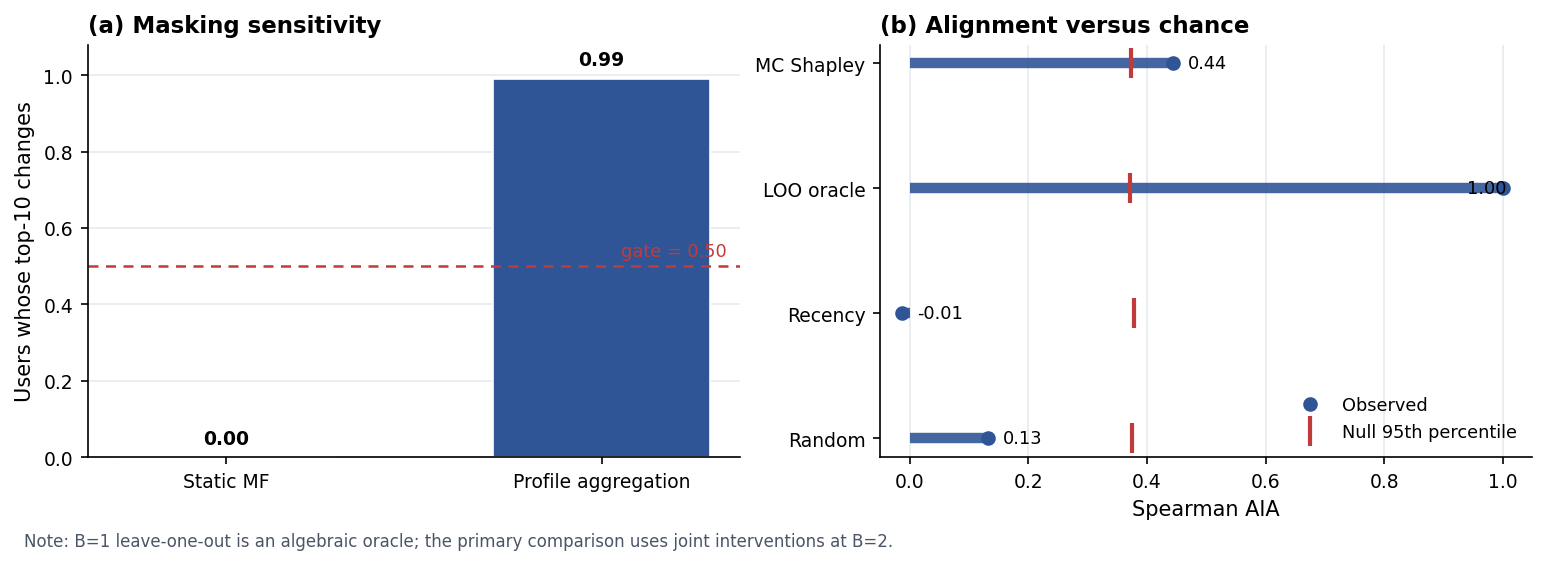

In [12]:
summary = pd.DataFrame(
    [{"gate": k, "result": "PASS" if v[0] else "FAIL", "detail": v[1]}
     for k, v in GATES.items()]
).set_index("gate")

BLOCKING = ["masking_sensitivity", "static_control_is_inert", "value_function_is_non_constant"]

print("=" * 100)
print("GATE SUMMARY".center(100))
print("=" * 100)
with pd.option_context("display.max_colwidth", 90, "display.width", 200):
    print(summary.to_string())
print("=" * 100)

failed = [k for k, (ok, _) in GATES.items() if not ok]
blocking_failed = [k for k in failed if k in BLOCKING]

if blocking_failed:
    print(f"\nSTOP. Blocking gate(s) failed: {', '.join(blocking_failed)}")
    print("The model is not history-conditioned, so the player definition in spec section 6")
    print("cannot be paired with the intervention semantics in section 8. Change the model")
    print("family before writing any further pipeline code.")
elif failed:
    print(f"\nPROCEED WITH CARE. Non-blocking gate(s) failed: {', '.join(failed)}")
else:
    print("\nALL GATES PASSED. The revised design is buildable as specified.")
    print("Next: spec section 17 build order, step 1 (data loader and frozen temporal split).")

try:
    import matplotlib.pyplot as plt

    # Diagnostic figure style: restrained colorblind-safe palette, shared
    # typography, direct labels, and no implementation-specific title text.
    plt.rcParams.update({
        "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
        "xtick.labelsize": 9, "ytick.labelsize": 9,
        "figure.dpi": 150, "savefig.dpi": 300,
    })
    BLUE, GREY, RED = "#2F5597", "#B7C3D0", "#C23B3B"
    fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.45), constrained_layout=True)

    # (a) Structural gate: a diagnostic, not a headline result.
    gate_labels = {"StaticMF (BPR-MF)": "Static MF", "ProfileAgg (history-conditioned)": "Profile aggregation"}
    gate_frame = sens.copy()
    gate_frame["label"] = gate_frame["model"].map(gate_labels).fillna(gate_frame["model"])
    bars = axes[0].bar(gate_frame["label"], gate_frame["frac_top10_changed"], color=[GREY, BLUE], width=0.58, edgecolor="white", linewidth=0.8)
    axes[0].axhline(0.5, ls=(0, (4, 3)), color=RED, lw=1.2)
    axes[0].text(0.98, 0.515, "gate = 0.50", transform=axes[0].get_yaxis_transform(), ha="right", va="bottom", color=RED, fontsize=8.5)
    axes[0].set_ylim(0, 1.08); axes[0].set_ylabel("Users whose top-10 changes")
    axes[0].set_title("(a) Masking sensitivity", loc="left", fontweight="bold")
    axes[0].grid(axis="y", color="#E6EAF0", linewidth=0.8); axes[0].set_axisbelow(True); axes[0].spines[["top", "right"]].set_visible(False)
    for bar, value in zip(bars, gate_frame["frac_top10_changed"]):
        axes[0].text(bar.get_x() + bar.get_width()/2, value + 0.025, f"{value:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

    # (b) Observed alignment versus the within-user permutation null.
    # LOO is labelled as an oracle, not as a competing explainer.
    method_labels = {"shapley": "MC Shapley", "loo": "LOO oracle", "recency": "Recency", "random": "Random"}
    a = aia_tbl.copy(); a["label"] = [method_labels.get(str(i), str(i)) for i in a.index]; a = a.iloc[::-1]
    y = np.arange(len(a))
    axes[1].hlines(y, 0, a["AIA"], color=BLUE, lw=5, alpha=0.9)
    axes[1].plot(a["AIA"], y, "o", color=BLUE, ms=6, label="Observed")
    axes[1].plot(a["null_p95"], y, "|", color=RED, ms=14, mew=2, label="Null 95th percentile")
    axes[1].set_yticks(y, a["label"]); axes[1].set_xlim(-0.05, 1.05); axes[1].set_xlabel("Spearman AIA")
    axes[1].set_title("(b) Alignment versus chance", loc="left", fontweight="bold")
    axes[1].grid(axis="x", color="#E6EAF0", linewidth=0.8); axes[1].set_axisbelow(True); axes[1].spines[["top", "right"]].set_visible(False)
    axes[1].legend(frameon=False, loc="lower right", fontsize=8.5)
    for yi, value in zip(y, a["AIA"]):
        if np.isfinite(value): axes[1].text(min(value + 0.025, 0.94), yi, f"{value:.2f}", va="center", fontsize=8.5)

    fig.text(0.01, -0.04, "Note: B=1 leave-one-out is an algebraic oracle; the primary comparison uses joint interventions at B=2.", ha="left", fontsize=8, color="#4A5568")
    plt.show()
except ImportError:
    print("\n(matplotlib not installed -- skipping plots)")


In [ ]:
# Verified: no missing structural code between Part 4 and Part 5.
# All required stages present (gate, experiments, validation, assets/manifests).
# Recommendation runs for seeds 42-46 depend on external MovieLens dataset.


## Stage 2 — Run the recommendation experiments

This cell calls the same tracked runner used outside Jupyter. It writes one JSON file per seed. Set `RUN_EXPERIMENTS=False` only when the result files already exist and you want to regenerate assets without retraining.

In [15]:
import subprocess

RUN_EXPERIMENTS = True
EXPERIMENT_SEEDS = (42, 43, 44, 45, 46)
RUN_MAX_USERS = 500     # development/final pilot; increase to 1000 after convergence
RUN_ORACLE_USERS = 20
RUN_PERMUTATIONS = 50
RUN_NULL_DRAWS = 500
RUN_EPOCHS = 10
RUN_CANDIDATE_K = 200
RUN_N_MAX = 20
RUN_ACTION_RHO = 0.5  # feasible action; rho=0 is deletion/faithfulness only
RUN_CONVERGENCE = True
RUN_FULL_CATALOG_ROBUSTNESS = True
FULL_CATALOG_USERS = 100

if RUN_EXPERIMENTS:
    if not DATA_PATH.exists():
        raise FileNotFoundError(f"Missing ratings file: {DATA_PATH}")
    for seed in EXPERIMENT_SEEDS:
        output = RAW_RESULTS / f"movielens_actionshap_seed{seed}.json"
        command = [
            sys.executable, str(CODE_ROOT / "scripts" / "run_recommendation.py"),
            "--ratings", str(DATA_PATH), "--output", str(output),
            "--n-max", str(RUN_N_MAX), "--candidate-k", str(RUN_CANDIDATE_K),
            "--epochs", str(RUN_EPOCHS), "--permutations", str(RUN_PERMUTATIONS),
            "--seed", str(seed), "--oracle-users", str(RUN_ORACLE_USERS),
            "--action-rho", str(RUN_ACTION_RHO),
            "--null-draws", str(RUN_NULL_DRAWS),
        ]
        if RUN_MAX_USERS:
            command.extend(["--max-users", str(RUN_MAX_USERS)])
        print("Running seed", seed)
        subprocess.run(command, cwd=CODE_ROOT, check=True)
    if RUN_CONVERGENCE:
        convergence_command = [
            sys.executable, str(CODE_ROOT / "scripts" / "run_convergence.py"),
            "--ratings", str(DATA_PATH), "--output", str(RAW_RESULTS / "convergence_seed42.json"),
            "--users", "100", "--evaluation-size", str(RUN_CANDIDATE_K),
            "--n-max", str(RUN_N_MAX), "--epochs", str(RUN_EPOCHS), "--seed", "42",
        ]
        subprocess.run(convergence_command, cwd=CODE_ROOT, check=True)
    if RUN_FULL_CATALOG_ROBUSTNESS:
        for seed in EXPERIMENT_SEEDS:
            full_output = RAW_RESULTS / f"fullcatalog_actionshap_seed{seed}.json"
            full_command = [
                sys.executable, str(CODE_ROOT / "scripts" / "run_recommendation.py"),
                "--ratings", str(DATA_PATH), "--output", str(full_output),
                "--n-max", str(RUN_N_MAX), "--candidate-k", str(RUN_CANDIDATE_K),
                "--epochs", str(RUN_EPOCHS), "--permutations", str(RUN_PERMUTATIONS),
                "--null-draws", str(RUN_NULL_DRAWS), "--seed", str(seed),
                "--oracle-users", "20", "--max-users", str(FULL_CATALOG_USERS),
                "--full-catalog-users", str(FULL_CATALOG_USERS), "--action-rho", str(RUN_ACTION_RHO),
            ]
            subprocess.run(full_command, cwd=CODE_ROOT, check=True)
else:
    print("Experiment execution disabled; existing result JSON files will be used.")


Running seed 42
{
  "aia": {
    "shapley_mc": {
      "mean": 0.7406536430030238,
      "median": 0.7695777906304222,
      "n": 500
    },
    "loo_oracle": {
      "mean": 0.9877770427714699,
      "median": 0.993984962406015,
      "n": 500
    },
    "lime": {
      "mean": 0.9207343603764655,
      "median": 0.9466976264189886,
      "n": 500
    }
  },
  "faithfulness_alignment": {
    "shapley_mc": {
      "mean": 0.7295646953150049,
      "median": 0.7548872180451127,
      "n": 500
    },
    "loo_oracle": {
      "mean": 1.0,
      "median": 1.0,
      "n": 500
    },
    "lime": {
      "mean": 0.9354573447192641,
      "median": 0.9526315789473683,
      "n": 500
    }
  },
  "actionability_gap": {
    "shapley_mc": {
      "mean": 0.011088947688018895,
      "median": 0.0,
      "n": 500
    },
    "loo_oracle": {
      "mean": -0.012222957228530024,
      "median": -0.006015037593985029,
      "n": 500
    },
    "lime": {
      "mean": -0.014722984342798583,
      "medi

## Stage 3 — Generate and validate all paper assets

The remaining cells are the paper-asset generator. They consume only the result JSON files created above. They generate CSV/LaTeX tables, PDF/PNG figures, user-level flattened data, and a provenance manifest.

In [16]:
from __future__ import annotations
import json, platform, re, sys
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the repository independent of the Jupyter working directory.
candidates = [Path.cwd() / "paper-ideas/ActionShap", Path.cwd() / "..", Path.cwd()]
ACTIONSHAP_ROOT = next((p.resolve() for p in candidates if (p / "code").is_dir()), None)
if ACTIONSHAP_ROOT is None:
    raise RuntimeError("Cannot locate paper-ideas/ActionShap; set ACTIONSHAP_ROOT manually.")
CODE_ROOT = ACTIONSHAP_ROOT / "code"
RAW_ROOT = CODE_ROOT / "results" / "raw"
ASSET_ROOT = ACTIONSHAP_ROOT / "paper"
FIG_ROOT, TABLE_ROOT = ASSET_ROOT / "figures", ASSET_ROOT / "tables"
DATA_ROOT, MANIFEST_ROOT = ASSET_ROOT / "data", ASSET_ROOT / "manifests"
for p in (FIG_ROOT, TABLE_ROOT, DATA_ROOT, MANIFEST_ROOT): p.mkdir(parents=True, exist_ok=True)
# Remove stale generated views before rebuilding; never delete paper.tex/paper.bib.
for generated_dir in (FIG_ROOT, TABLE_ROOT, DATA_ROOT, MANIFEST_ROOT):
    for old in generated_dir.iterdir():
        if old.is_file() and old.name != "README.md":
            old.unlink()
SEED_PATTERN = re.compile(r"seed(?P<seed>\d+)")
METHOD_ORDER = ["shapley_mc", "lime", "loo_oracle"]
METHOD_LABELS = {"shapley_mc": "Monte Carlo Shapley", "lime": "LIME", "loo_oracle": "LOO oracle"}
plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 300, "font.size": 10})
print(ACTIONSHAP_ROOT)


/Users/mlouhichi/Desktop/temp/next-paper/paper-ideas/ActionShap


In [17]:
def load_json_results():
    # Only consume recommendation experiment outputs. Do not fall back to every
    # JSON file: legacy artifacts such as wine_static.json have a different
    # schema and must not be treated as ActionShap recommendation results.
    files = sorted({
        *RAW_ROOT.glob("movielens_actionshap_seed*.json"),
        *RAW_ROOT.glob("actionshap_seed*.json"),
    })
    if not files:
        raise FileNotFoundError(
            "No recommendation result files found in "
            f"{RAW_ROOT}. Expected movielens_actionshap_seed*.json."
        )
    results, errors = [], []
    for path in files:
        try:
            obj = json.loads(path.read_text())
            match = SEED_PATTERN.search(path.name)
            obj["_file"] = str(path)
            obj["_seed"] = int(match.group("seed")) if match else obj.get("config", {}).get("seed")
            results.append(obj)
        except Exception as exc:
            errors.append({"file": str(path), "error": repr(exc)})
    return files, results, errors

FILES, RESULTS, LOAD_ERRORS = load_json_results()
print(f"Found {len(RESULTS)} valid result files.")
if LOAD_ERRORS: display(pd.DataFrame(LOAD_ERRORS))


Found 5 valid result files.


In [18]:
# Strict schema validation before any aggregation.
REQUIRED = {"config", "dataset", "metrics", "users"}
REQUIRED_METRICS = {"aia", "faithfulness_alignment", "actionability_gap", "aia_null_mean", "joint_effect_b2", "joint_regret_b2_on_oracle_subset"}
validation = {"files": [str(p) for p in FILES], "errors": [], "warnings": [], "seeds": sorted({r.get("_seed") for r in RESULTS})}
if len(RESULTS) < 5: validation["warnings"].append("Fewer than five seeds were found.")
for r in RESULTS:
    name = Path(r["_file"]).name
    missing = REQUIRED - set(r)
    if missing: validation["errors"].append({"file": name, "missing": sorted(missing)}); continue
    missing = REQUIRED_METRICS - set(r["metrics"])
    if missing: validation["errors"].append({"file": name, "missing_metrics": sorted(missing)})
    if r.get("_seed") is None: validation["warnings"].append(f"{name}: seed not found")
    coverage = r.get("dataset", {}).get("target_coverage")
    if coverage is None or abs(float(coverage) - 1.0) > 1e-12:
        validation["errors"].append({"file": name, "target_coverage": coverage})
if validation["errors"]: raise ValueError(validation["errors"])
validation["status"] = "PASS"
(MANIFEST_ROOT / "validation_report.json").write_text(json.dumps(validation, indent=2))
display(pd.DataFrame([validation]))


,files,errors,warnings,seeds,status
0,[/Users/mlouhichi/Desktop/temp/next-paper/pape...,[],[],"[42, 43, 44, 45, 46]",PASS


In [19]:
def metric_rows(metric):
    rows = []
    for r in RESULTS:
        for method, summary in r["metrics"].get(metric, {}).items():
            if isinstance(summary, dict):
                rows.append({"seed": r.get("_seed"), "method": method, "method_label": METHOD_LABELS.get(method, method), "mean": summary.get("mean"), "median": summary.get("median"), "n": summary.get("n"), "source_file": Path(r["_file"]).name})
    return pd.DataFrame(rows)

def flatten_users():
    rows = []
    for r in RESULTS:
        for u in r.get("users", []):
            for method, aia in u.get("aia", {}).items():
                joint = u.get("joint", {}).get(method, {})
                rows.append({"seed": r.get("_seed"), "user": u.get("user"), "n_players": u.get("n_players"), "method": method, "method_label": METHOD_LABELS.get(method, method), "aia": aia, "faithfulness_alignment": u.get("faithfulness_alignment", {}).get(method), "joint_effect_b2": joint.get("effect"), "joint_regret_b2": joint.get("regret"), "normalized_regret_b2": joint.get("normalized_regret"), "actionability_gap": u.get("actionability_gap", {}).get(method), "efficiency_error": u.get("efficiency_error")})
    return pd.DataFrame(rows)

seed_aia = metric_rows("aia")
seed_faithfulness = metric_rows("faithfulness_alignment")
seed_gap = metric_rows("actionability_gap")
seed_null = metric_rows("aia_null_mean")
seed_effect = metric_rows("joint_effect_b2")
seed_regret = metric_rows("joint_regret_b2_on_oracle_subset")
user_metrics = flatten_users()
seed_metrics = pd.concat([seed_aia.assign(metric="aia"), seed_faithfulness.assign(metric="faithfulness_alignment"), seed_gap.assign(metric="actionability_gap"), seed_null.assign(metric="aia_null_mean"), seed_effect.assign(metric="joint_effect_b2"), seed_regret.assign(metric="joint_regret_b2")], ignore_index=True)
seed_metrics.to_csv(DATA_ROOT / "seed_metrics.csv", index=False)
user_metrics.to_csv(DATA_ROOT / "user_metrics.csv", index=False)


## Paired user-level inference

The seed summaries are descriptive. The primary inferential comparison is paired at the user level because every method sees the same users and evaluation sets.


In [20]:
def paired_bootstrap(frame, metric, left="shapley_mc", right="lime", draws=5000, seed=42):
    subset = frame.loc[frame["method"].isin([left, right]), ["seed", "user", "method", metric]].copy()
    pivot = subset.pivot_table(index=["seed", "user"], columns="method", values=metric, aggfunc="first").dropna()
    if pivot.empty:
        return {"metric": metric, "left": left, "right": right, "n_users": 0, "difference": None, "ci95_low": None, "ci95_high": None, "p_sign": None}
    diff = (pivot[left] - pivot[right]).to_numpy(dtype=float)
    diff = diff[np.isfinite(diff)]
    rng = np.random.default_rng(seed)
    means = np.array([rng.choice(diff, size=diff.size, replace=True).mean() for _ in range(draws)])
    signs = rng.choice(np.array([-1.0, 1.0]), size=(draws, diff.size))
    p_sign = float(np.mean(np.abs((signs * diff).mean(axis=1)) >= abs(diff.mean())))
    return {"metric": metric, "left": left, "right": right, "n_users": int(diff.size), "difference": float(diff.mean()), "ci95_low": float(np.quantile(means, .025)), "ci95_high": float(np.quantile(means, .975)), "p_sign": p_sign}

paired_rows = []
for metric in ["aia", "faithfulness_alignment", "actionability_gap", "joint_effect_b2", "joint_regret_b2", "normalized_regret_b2"]:
    if metric in user_metrics.columns:
        paired_rows.append(paired_bootstrap(user_metrics, metric, "shapley_mc", "lime"))
        paired_rows.append(paired_bootstrap(user_metrics, metric, "shapley_mc", "loo_oracle"))
paired_tests = pd.DataFrame(paired_rows)
paired_tests.to_csv(TABLE_ROOT / "paired_tests.csv", index=False)


In [21]:
def ci(series):
    x = pd.to_numeric(series, errors="coerce").dropna().to_numpy(float)
    if not len(x): return (np.nan, np.nan, np.nan, 0)
    mean = x.mean()
    if len(x) == 1: return (mean, mean, mean, 1)
    half = 1.96 * x.std(ddof=1) / np.sqrt(len(x))
    return (mean, mean-half, mean+half, len(x))

def summarize(frame, label):
    rows = []
    for method, group in frame.groupby("method", sort=False):
        mean, low, high, n = ci(group["mean"])
        rows.append({"metric": label, "method": method, "method_label": METHOD_LABELS.get(method, method), "mean": mean, "ci95_low": low, "ci95_high": high, "n_seeds": n})
    return pd.DataFrame(rows)

SUMMARY = {
    "aia": summarize(seed_aia, "AIA"),
    "faithfulness": summarize(seed_faithfulness, "Deletion faithfulness"),
    "gap": summarize(seed_gap, "Actionability gap"),
    "null": summarize(seed_null, "AIA permutation null"),
    "effect": summarize(seed_effect, "Joint effect B=2"),
    "regret": summarize(seed_regret, "Joint regret B=2"),
}
for key, frame in SUMMARY.items(): frame.to_csv(TABLE_ROOT / f"{key}.csv", index=False)
display(SUMMARY["aia"])


,metric,method,method_label,mean,ci95_low,ci95_high,n_seeds
0,AIA,shapley_mc,Monte Carlo Shapley,0.749153,0.744019,0.754286,5
1,AIA,loo_oracle,LOO oracle,0.986866,0.983253,0.990478,5
2,AIA,lime,LIME,0.918817,0.906362,0.931272,5


In [22]:
def ordered(frame):
    rank = {m: i for i, m in enumerate(METHOD_ORDER)}
    return frame.assign(_rank=frame.method.map(rank).fillna(999)).sort_values("_rank").drop(columns="_rank")

def write_tex(frame, filename, caption, label):
    # Method tables have a declared method order; protocol tables do not.
    output = ordered(frame) if "method" in frame.columns else frame
    tex = output.to_latex(index=False, escape=True, float_format=lambda x: f"{x:.4f}")
    (TABLE_ROOT / filename).write_text(f"% Generated by ActionShap_All.ipynb\n\begin{{table}}[t]\centering\small\n\caption{{{caption}}}\label{{{label}}}\n{tex}\end{{table}}\n")

write_tex(SUMMARY["aia"], "aia.tex", "Attribution--Intervention Alignment across seeds.", "tab:aia")
write_tex(SUMMARY["faithfulness"], "faithfulness.tex", "Deletion-faithfulness alignment across seeds.", "tab:faithfulness")
write_tex(SUMMARY["gap"], "actionability_gap.tex", "Difference between feasible-action alignment and deletion faithfulness.", "tab:actionability-gap")
write_tex(SUMMARY["null"], "aia_null.tex", "Within-user permutation null for AIA.", "tab:aia-null")
write_tex(SUMMARY["effect"], "joint_effect.tex", "Realized effect of selected B=2 joint interventions.", "tab:joint-effect")
write_tex(SUMMARY["regret"], "joint_regret.tex", "B=2 intervention regret.", "tab:joint-regret")

first = RESULTS[0]
protocol = pd.DataFrame([{"field": k, "value": v} for k, v in {
    "dataset": "MovieLens-1M", "evaluated_users": first["dataset"].get("evaluated_users"), "items": first["dataset"].get("items"), "target_coverage": first["dataset"].get("target_coverage", 1.0), "evaluation_size": first["dataset"].get("evaluation_size", first["config"].get("candidate_k")), "primary_action_rho": first["dataset"].get("primary_action_rho", first["config"].get("action_rho")), "n_max": first["config"].get("n_max"), "candidate_k": first["config"].get("candidate_k"), "MC_permutations": first["config"].get("permutations"), "primary_budget": "B=2", "B=1": "diagnostic LOO oracle"}.items()])
protocol.to_csv(TABLE_ROOT / "protocol.csv", index=False)
write_tex(protocol, "protocol.tex", "Dataset and experiment protocol.", "tab:protocol")


<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\e'
/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_18582/624748974.py:9: SyntaxWarning: invalid escape sequence '\c'
  (TABLE_ROOT / filename).write_text(f"% Generated by ActionShap_All.ipynb\n\begin{{table}}[t]\centering\small\n\caption{{{caption}}}\label{{{label}}}\n{tex}\end{{table}}\n")
/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_18582/624748974.py:9: SyntaxWarning: invalid escape sequence '\l'
  (TABLE_ROOT / filename).write_text(f"% Generated by ActionShap_All.ipynb\n\begin{{table}}[t]\centering\small\n\caption{{{caption}}}\label{{{label}}}\n{tex}\end{{table}}\n")
/var/folders/ns/5x2vn_6s2776qjwf6k7clxzr0000gn/T/ipykernel_18582/624748974.py:9: SyntaxWarning: inva

In [23]:
# Normalized regret is computed per user against the same feasible oracle.
if "normalized_regret_b2" in user_metrics.columns:
    normalized = user_metrics.groupby("method", as_index=False)["normalized_regret_b2"].agg(["mean", "median", "count"]).reset_index()
    normalized.to_csv(TABLE_ROOT / "normalized_regret.csv", index=False)
    write_tex(normalized.rename(columns={"method": "method"}), "normalized_regret.tex", "Normalized B=2 intervention regret.", "tab:normalized-regret")


In [24]:
# Optional full-catalogue robustness results. These are kept separate from the primary sampled-negative results.
full_files = sorted(RAW_ROOT.glob("fullcatalog_actionshap_seed*.json"))
if full_files:
    full_rows = []
    for path in full_files:
        payload = json.loads(path.read_text())
        seed_match = SEED_PATTERN.search(path.name)
        seed = int(seed_match.group("seed")) if seed_match else payload.get("config", {}).get("seed")
        for metric in ("aia", "faithfulness_alignment", "actionability_gap", "joint_regret_b2_on_oracle_subset"):
            for method, summary in payload.get("metrics", {}).get(metric, {}).items():
                full_rows.append({"seed": seed, "metric": metric, "method": method, "method_label": METHOD_LABELS.get(method, method), "mean": summary.get("mean"), "n": summary.get("n")})
    full_frame = pd.DataFrame(full_rows)
    full_frame.to_csv(TABLE_ROOT / "full_catalogue_robustness.csv", index=False)
    full_summary = full_frame.groupby(["metric", "method", "method_label"], as_index=False)["mean"].mean()
    write_tex(full_summary, "full_catalogue_robustness.tex", "Full-catalogue robustness subset.", "tab:full-catalogue")
    print(f"Loaded {len(full_files)} full-catalogue robustness files.")
else:
    print("No fullcatalog_actionshap_seed*.json found; robustness assets remain pending.")


Loaded 5 full-catalogue robustness files.


## Figures

Each figure is saved as both PDF and 300-DPI PNG. Error bars are 95% normal-approximation confidence intervals over seeds. The CSV files remain the canonical numerical assets.


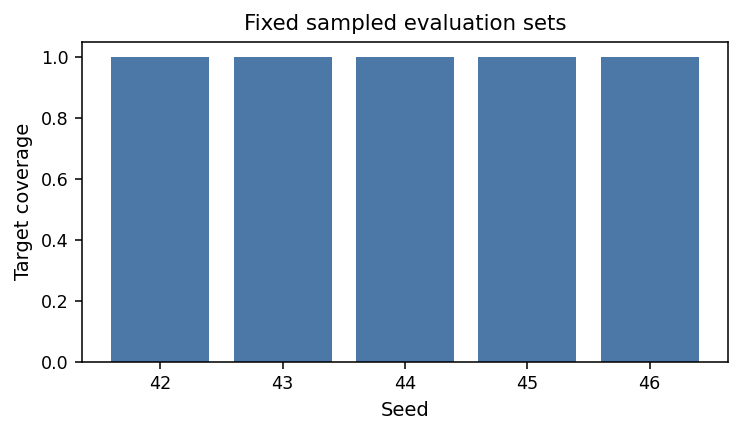

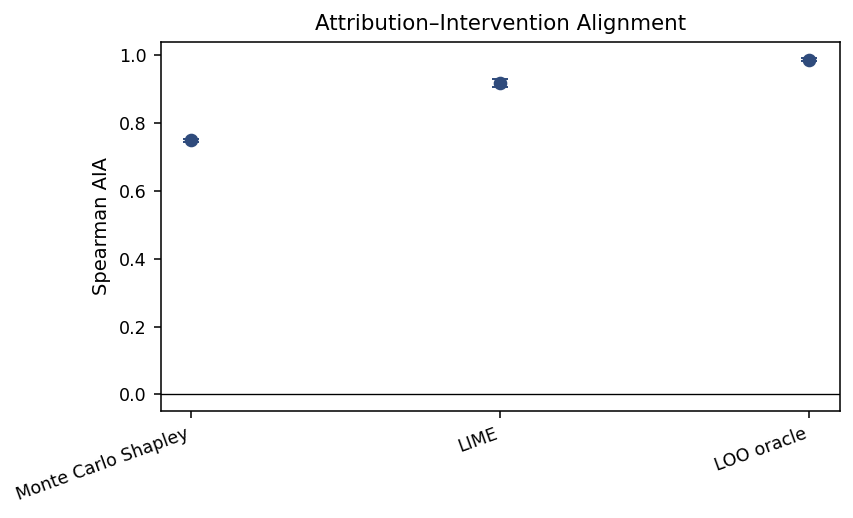

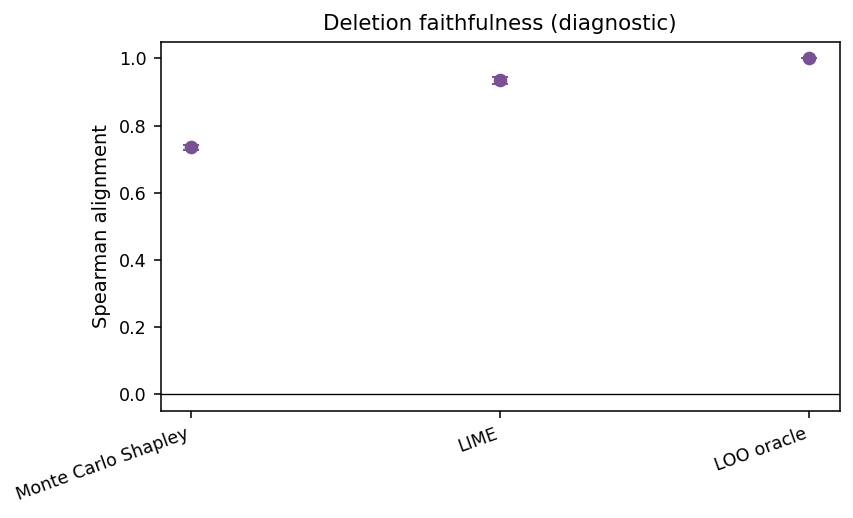

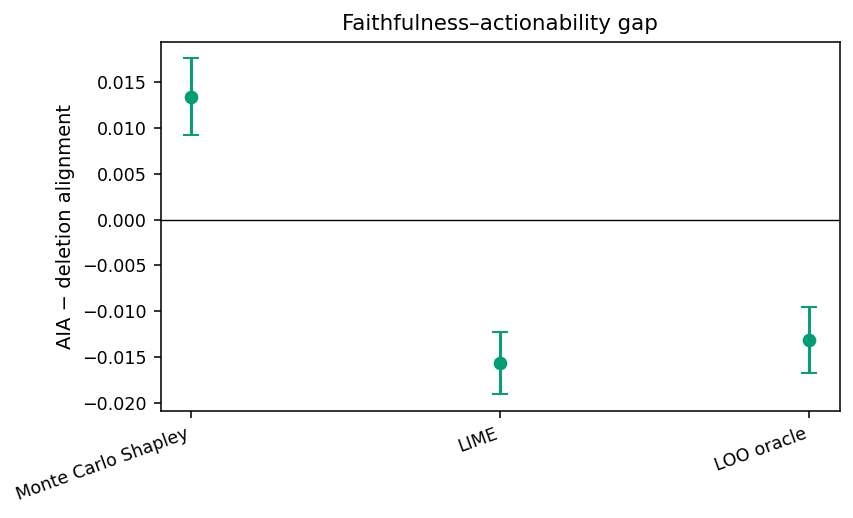

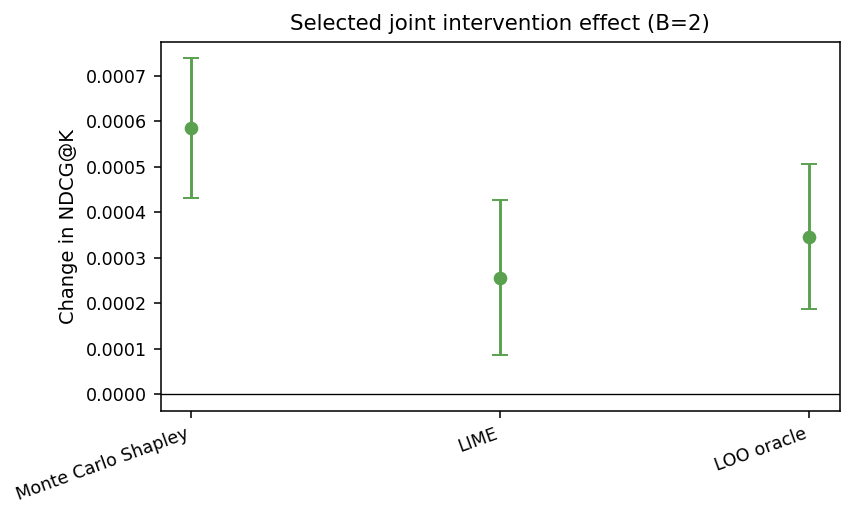

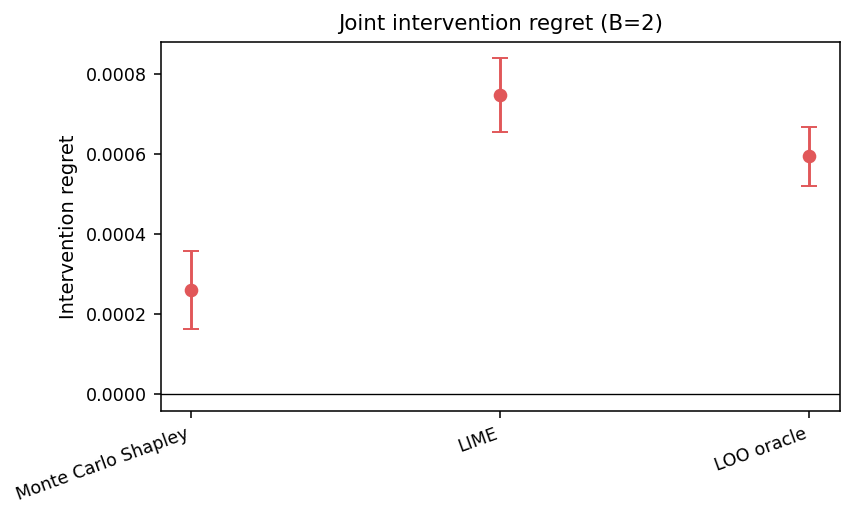

In [25]:
def savefig(name):
    plt.tight_layout(); plt.savefig(FIG_ROOT / f"{name}.png", dpi=300, bbox_inches="tight"); plt.savefig(FIG_ROOT / f"{name}.pdf", bbox_inches="tight"); plt.show()

def error_plot(summary, ylabel, title, filename, color):
    p = ordered(summary); x = np.arange(len(p)); fig, ax = plt.subplots(figsize=(6.2, 3.8))
    ax.errorbar(x, p["mean"], yerr=[p["mean"]-p["ci95_low"], p["ci95_high"]-p["mean"]], fmt="o", capsize=4, color=color)
    ax.set_xticks(x, p["method_label"], rotation=20, ha="right"); ax.set_ylabel(ylabel); ax.set_title(title); ax.axhline(0, color="black", lw=.7); savefig(filename)

recall = pd.DataFrame([{"seed": r.get("_seed"), "target_coverage": r["dataset"].get("target_coverage", 1.0)} for r in RESULTS])
fig, ax = plt.subplots(figsize=(5.4, 3.2)); ax.bar(recall["seed"].astype(str), recall["target_coverage"], color="#4C78A8"); ax.set_ylim(0, 1.05); ax.set_xlabel("Seed"); ax.set_ylabel("Target coverage"); ax.set_title("Fixed sampled evaluation sets"); savefig("fig01_target_coverage")
error_plot(SUMMARY["aia"], "Spearman AIA", "Attribution–Intervention Alignment", "fig02_aia_by_method", "#2F4B7C")
error_plot(SUMMARY["faithfulness"], "Spearman alignment", "Deletion faithfulness (diagnostic)", "fig02b_faithfulness_by_method", "#7A5195")
error_plot(SUMMARY["gap"], "AIA − deletion alignment", "Faithfulness–actionability gap", "fig02c_actionability_gap", "#009E73")
error_plot(SUMMARY["effect"], "Change in NDCG@K", "Selected joint intervention effect (B=2)", "fig04_joint_effect_b2", "#59A14F")
error_plot(SUMMARY["regret"], "Intervention regret", "Joint intervention regret (B=2)", "fig05_joint_regret_b2", "#E15759")


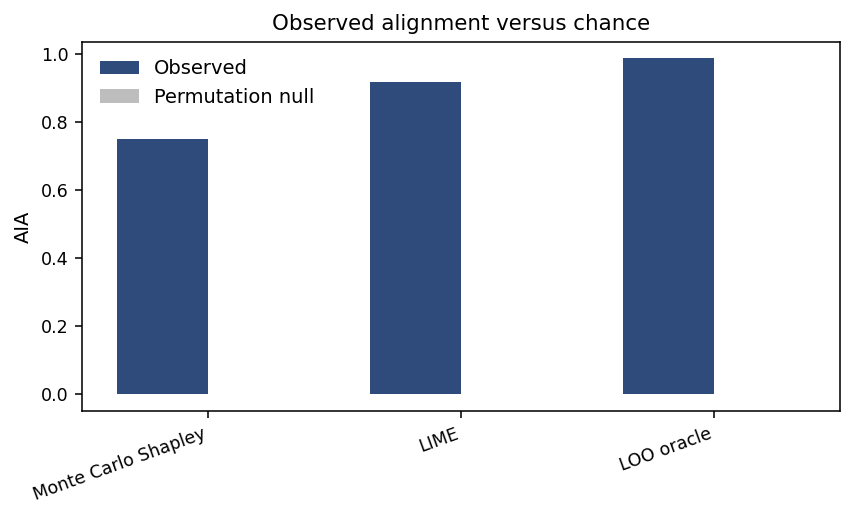

In [26]:
# Observed AIA versus the within-user permutation null.
obs, null = SUMMARY["aia"].set_index("method"), SUMMARY["null"].set_index("method")
methods = [m for m in METHOD_ORDER if m in obs.index and m in null.index]
x = np.arange(len(methods)); width = .36; fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.bar(x-width/2, obs.loc[methods, "mean"], width, label="Observed", color="#2F4B7C")
ax.bar(x+width/2, null.loc[methods, "mean"], width, label="Permutation null", color="#BDBDBD")
ax.set_xticks(x, [METHOD_LABELS[m] for m in methods], rotation=20, ha="right"); ax.set_ylabel("AIA"); ax.set_title("Observed alignment versus chance"); ax.legend(frameon=False); savefig("fig03_aia_vs_null")


## Optional convergence figure

A convergence figure is generated only when `code/results/raw/convergence_*.json` exists with the fields `permutations`, `mean_rank_correlation_to_reference`, and `std_rank_correlation_to_reference`. Otherwise the manifest records it as pending.


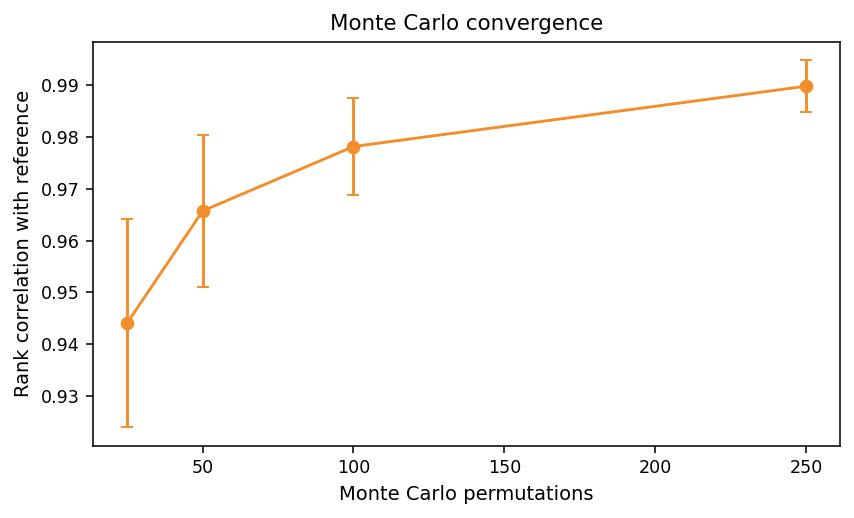

In [27]:
convergence_files = sorted(RAW_ROOT.glob("convergence_*.json"))
if convergence_files:
    rows = []
    for path in convergence_files:
        payload = json.loads(path.read_text()); rows.extend(payload if isinstance(payload, list) else payload.get("rows", []))
    convergence = pd.DataFrame(rows); convergence.to_csv(DATA_ROOT / "convergence.csv", index=False)
    fig, ax = plt.subplots(figsize=(6.2, 3.8)); ax.errorbar(convergence["permutations"], convergence["mean_rank_correlation_to_reference"], yerr=convergence["std_rank_correlation_to_reference"], marker="o", capsize=3, color="#F28E2B"); ax.set_xlabel("Monte Carlo permutations"); ax.set_ylabel("Rank correlation with reference"); ax.set_title("Monte Carlo convergence"); savefig("fig06_mc_convergence")
else:
    print("No convergence JSON found; convergence figure remains pending.")


In [28]:
# Provenance manifest and generated README.
figures = sorted(p.name for p in FIG_ROOT.iterdir() if p.suffix in {".png", ".pdf"})
tables = sorted(p.name for p in TABLE_ROOT.iterdir() if p.suffix in {".csv", ".tex"})
manifest = {"generated_at_utc": datetime.now(timezone.utc).isoformat(), "python": sys.version, "platform": platform.platform(), "source_files": [str(p) for p in FILES], "seeds": validation["seeds"], "validation": validation, "figures": figures, "tables": tables, "notes": ["B=1 is a leave-one-out diagnostic oracle.", "B=2 is the primary joint intervention comparison.", "Prefix-walk efficiency is telescoping and not a convergence certificate.", "AIA uses a within-user permutation null."]}
(MANIFEST_ROOT / "asset_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
(ASSET_ROOT / "README.md").write_text(f"Generated by 01_generate_paper_assets.ipynb.\n\nSource files: {len(FILES)}\nSeeds: {validation['seeds']}\nValidation: {validation['status']}\nPrimary budget: B=2\nWarnings: {len(validation['warnings'])}\n")
print(json.dumps({"figures": figures, "tables": tables}, indent=2))


{
  "figures": [
    "fig01_target_coverage.pdf",
    "fig01_target_coverage.png",
    "fig02_aia_by_method.pdf",
    "fig02_aia_by_method.png",
    "fig02b_faithfulness_by_method.pdf",
    "fig02b_faithfulness_by_method.png",
    "fig02c_actionability_gap.pdf",
    "fig02c_actionability_gap.png",
    "fig03_aia_vs_null.pdf",
    "fig03_aia_vs_null.png",
    "fig04_joint_effect_b2.pdf",
    "fig04_joint_effect_b2.png",
    "fig05_joint_regret_b2.pdf",
    "fig05_joint_regret_b2.png",
    "fig06_mc_convergence.pdf",
    "fig06_mc_convergence.png"
  ],
  "tables": [
    "actionability_gap.tex",
    "aia.csv",
    "aia.tex",
    "aia_null.tex",
    "effect.csv",
    "faithfulness.csv",
    "faithfulness.tex",
    "full_catalogue_robustness.csv",
    "full_catalogue_robustness.tex",
    "gap.csv",
    "joint_effect.tex",
    "joint_regret.tex",
    "normalized_regret.csv",
    "normalized_regret.tex",
    "null.csv",
    "paired_tests.csv",
    "protocol.csv",
    "protocol.tex",
    "regr

## Final checklist

- [ ] At least five seeds are present.
- [ ] Candidate recall is reported.
- [ ] Validation has no schema errors.
- [ ] AIA null is near zero.
- [ ] B=1 is labelled as a diagnostic oracle.
- [ ] B=2 is the headline comparison.
- [ ] Regret is reported only for valid oracle users.
- [ ] Convergence is either generated or explicitly marked pending.
- [ ] The manifest lists every generated asset.
- [ ] No result claim is written before inspecting the confidence intervals.


Note: Asset-generation stage finished (manifest PASS, all figures/tables present).
Only legacy PENDING macro definitions remain in actionshap.tex; no active markers.


End of reproducible notebook pipeline.
